In [16]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

In [17]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
except ValueError:
    tpu = None

if tpu:
    policyConfig = "mixed_bfloat16"
else:
    policyConfig = "mixed_float16"
policy = tf.keras.mixed_precision.Policy(policyConfig)
tf.keras.mixed_precision.set_global_policy(policy)

In [18]:
train_dir = "/home/felipeserver/Documents/datasets/actions/Human Action Recognition/main_data/train"
test_dir = "/home/felipeserver/Documents/datasets/actions/Human Action Recognition/main_data/test"

In [19]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode="categorical",
                                                                 batch_size=32,
                                                                 image_size=(224,224),
                                                                 shuffle=True)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                 label_mode="categorical",
                                                                 batch_size=32,
                                                                 image_size=(224,224),
                                                                 shuffle=False)

Found 10080 files belonging to 15 classes.
Found 2520 files belonging to 15 classes.


In [20]:
class_names = train_data.class_names
class_names

['calling',
 'clapping',
 'cycling',
 'dancing',
 'drinking',
 'eating',
 'fighting',
 'hugging',
 'laughing',
 'listening_to_music',
 'running',
 'sitting',
 'sleeping',
 'texting',
 'using_laptop']

In [21]:
def view_random_img(train_dir, target_class):
    directory = os.path.join(train_dir, target_class)
    random_img = random.sample(os.listdir(directory),1)

    img = mpimg.imread(os.path.join(directory, random_img[0]))
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");

    return img

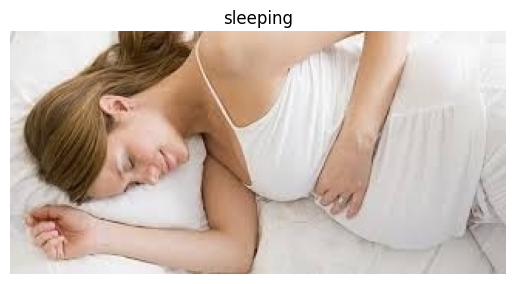

In [22]:
img = view_random_img(train_dir, random.choice(os.listdir(train_dir)))

In [23]:
checkpoint_path = "checkpoints/checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    save_best_only=True,
    monitor="val_accuracy",
    save_freq="epoch",
    verbose=1
)

In [24]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    verbose=1
)

In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.02),
    #tf.keras.layers.RandomFlip(),
    #tf.keras.layers.Rescaling(1./255)
])

In [26]:
#base model
base_model = tf.keras.applications.EfficientNetV2M(include_top=False)
base_model.trainable=False
inputs = tf.keras.layers.Input(shape=(224,224,3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
#x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dense(len(class_names))(x)
outputs = tf.keras.layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)

model_0 = tf.keras.Model(inputs, outputs)
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"]
)


In [27]:
model_0.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 15)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,169,603 (202.83 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

In [28]:
model_0_loss = model_0.fit(train_data,
                           epochs=10,
                           validation_data=test_data,
                           validation_steps=int(0.15 * len(test_data)),
                           callbacks=[checkpoint_callback])

Epoch 1/10


315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5680 - loss: 1.4083
Epoch 1: val_accuracy improved from -inf to 0.64489, saving model to checkpoints/checkpoint.weights.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 58s 130ms/step - accuracy: 0.5682 - loss: 1.4078 - val_accuracy: 0.6449 - val_loss: 1.1846
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6796 - loss: 1.0727
Epoch 2: val_accuracy improved from 0.64489 to 0.84091, saving model to checkpoints/checkpoint.weights.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6796 - loss: 1.0727 - val_accuracy: 0.8409 - val_loss: 0.6178
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7146 - loss: 0.9545
Epoch 3: val_accuracy did not improve from 0.84091
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.7146 - loss: 0.9545 - val_accuracy: 0.8295 - val_loss: 0.6355
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7136 - loss: 0.9558
Epoch 4: val_accuracy did not improve f

2024-06-06 11:15:16.802511: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-06-06 11:15:16.803277: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]



Epoch 8: val_accuracy did not improve from 0.84091
315/315 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.7469 - loss: 0.8500 - val_accuracy: 0.7500 - val_loss: 0.8770
Epoch 9/10
  1/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.6250 - loss: 0.9641

/home/felipeserver/miniconda3/envs/tflow/lib/python3.11/contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7501 - loss: 0.8265
Epoch 9: val_accuracy did not improve from 0.84091
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.7501 - loss: 0.8265 - val_accuracy: 0.5994 - val_loss: 1.6268
Epoch 10/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7665 - loss: 0.7997
Epoch 10: val_accuracy did not improve from 0.84091
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.7665 - loss: 0.7997 - val_accuracy: 0.8182 - val_loss: 0.9172


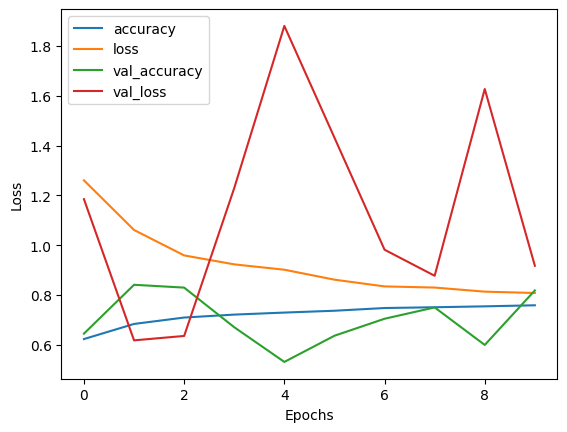

In [30]:
pd.DataFrame(model_0_loss.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [31]:

model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.6951 - loss: 1.2268


[1.3152843713760376, 0.6702380776405334]

In [32]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable=False



In [34]:
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(0.0001),
                metrics=["accuracy"])

In [35]:
model_0_new_loss = model_0.fit(train_data,
                               epochs=20,
                               initial_epoch=model_0_loss.epoch[-1],
                               validation_data=test_data,
                               validation_steps=int(0.15 * len(test_data)))

Epoch 10/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 60s 130ms/step - accuracy: 0.7478 - loss: 0.8506 - val_accuracy: 0.6847 - val_loss: 1.2446
Epoch 11/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.8179 - loss: 0.5666 - val_accuracy: 0.8523 - val_loss: 0.6174
Epoch 12/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.8553 - loss: 0.4428 - val_accuracy: 0.8466 - val_loss: 0.5679
Epoch 13/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.8766 - loss: 0.3709 - val_accuracy: 0.7585 - val_loss: 0.9870
Epoch 14/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.8926 - loss: 0.3248 - val_accuracy: 0.6790 - val_loss: 1.3438
Epoch 15/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9131 - loss: 0.2663 - val_accuracy: 0.6932 - val_loss: 1.2469
Epoch 16/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9242 - loss: 0.2372 - val_accuracy: 0.6733 - val_loss: 1.2903
Epoch 17/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9349 - 

2024-06-06 11:30:26.075783: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-06-06 11:30:26.076373: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]


315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.9349 - loss: 0.2110 - val_accuracy: 0.8036 - val_loss: 0.7090
Epoch 18/20
  1/315 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - accuracy: 0.9375 - loss: 0.2670

/home/felipeserver/miniconda3/envs/tflow/lib/python3.11/contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9443 - loss: 0.1829 - val_accuracy: 0.6932 - val_loss: 1.2194
Epoch 19/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9450 - loss: 0.1713 - val_accuracy: 0.8636 - val_loss: 0.6938
Epoch 20/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.9511 - loss: 0.1576 - val_accuracy: 0.8551 - val_loss: 0.5730


In [36]:
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.7467 - loss: 1.0735


[1.1028871536254883, 0.7412698268890381]

In [37]:
model_0.save("model_0.keras")

In [38]:
model = tf.keras.models.load_model("model_0.keras")

In [39]:
results = model.evaluate(test_data)
pred_probs = model.predict(test_data, verbose=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7467 - loss: 1.0735
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step


In [40]:
pred_classes = pred_probs.argmax(axis=1)
pred_classes

array([11,  4,  0, ..., 12, 14, 14])

In [41]:
y_labels = [labels.numpy().argmax() for images, labels in test_data.unbatch()]
y_labels

2024-06-06 11:36:33.471455: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [43]:
from sklearn.metrics import accuracy_score
sk_acc = accuracy_score(y_true=y_labels, y_pred=pred_classes)
sk_acc

0.7412698412698413

In [44]:
class_names

['calling',
 'clapping',
 'cycling',
 'dancing',
 'drinking',
 'eating',
 'fighting',
 'hugging',
 'laughing',
 'listening_to_music',
 'running',
 'sitting',
 'sleeping',
 'texting',
 'using_laptop']

In [45]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False): 
 
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] 
  n_classes = cm.shape[0] 


  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.RdPu) 
  fig.colorbar(cax)


  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])
  

  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), 
         yticks=np.arange(n_classes), 
         xticklabels=labels) 
  
  
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)
  threshold = (cm.max() + cm.min()) / 2.

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  if savefig:
    fig.savefig("confusion_matrix.png")

In [46]:
make_confusion_matrix(y_true=y_labels, y_pred=pred_classes, classes=class_names, figsize=(100,100), text_size=30)

In [47]:
def load_and_prep_image(filename, img_shape=224, scale=True):
  img = tf.io.read_file(filename)
  img = tf.io.decode_image(img, channels=3)
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    return img/255.
  else:
    return img

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


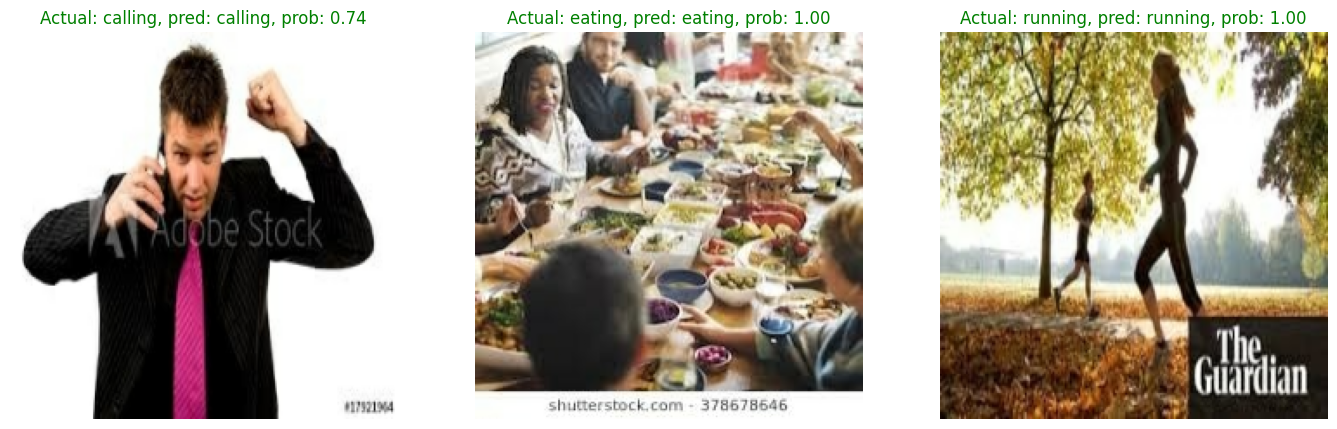

In [48]:
plt.figure(figsize=(17,10))
for i in range(3):
  class_name = random.choice(class_names)
  filename = random.choice(os.listdir(test_dir+"/"+class_name))
  filepath = test_dir + "/" + class_name + "/" + filename

  img = load_and_prep_image(filepath, scale=False)
  img_expanded = tf.expand_dims(img, axis=0)
  pred_prob = model.predict(img_expanded)
  pred_class = class_names[pred_prob.argmax()]

  plt.subplot(1,3,i+1)
  plt.imshow(img/255.)
  if class_name == pred_class:
    title_color = "g"
  else:
    title_color = "r"

  plt.title(f"Actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
  plt.axis("off");

In [49]:
img_dir = "/home/felipeserver/Pictures/inference/actions"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


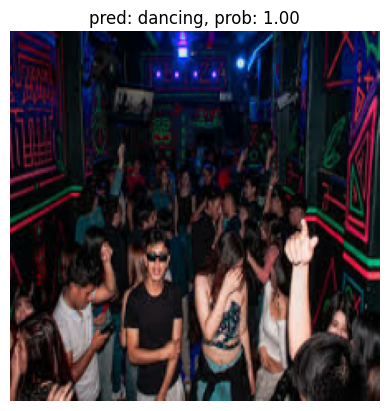

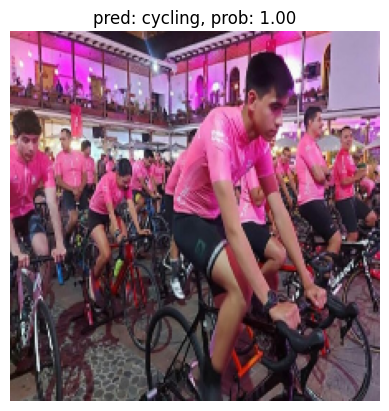

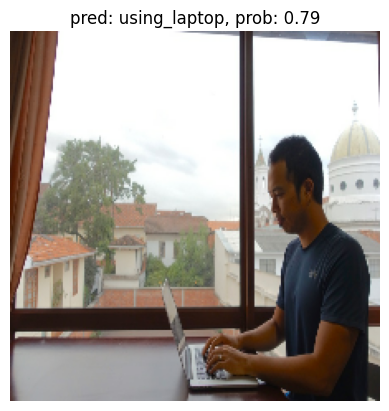

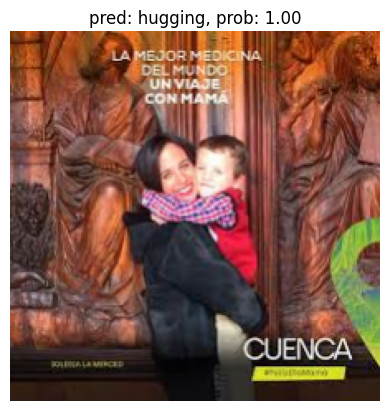

In [50]:
for image in os.listdir(img_dir):
    img = load_and_prep_image(os.path.join(img_dir,image), scale=False)
    pred_prob = model.predict(tf.expand_dims(img, axis=0))
    pred_class = class_names[pred_prob.argmax()]

    plt.figure()
    plt.imshow(img/255.)
    plt.title(f"pred: {pred_class}, prob: {pred_prob.max():.2f}")
    plt.axis('off');